# Système de Recommandation de Livres
## Book Crossing Dataset — Text Mining & Recommender Systems

---

### Objectifs du projet
Ce notebook implémente plusieurs approches de recommandation de livres :

1. **Recommandation par popularité** — Livres les plus notés/populaires
2. **Filtrage collaboratif item-item** — Basé sur la similarité entre livres
3. **Filtrage basé sur le contenu** — Basé sur les métadonnées (titre, auteur)

### Dataset : Book-Crossing
| Fichier | Description |
|---------|-------------|
| `Books.csv` | ~271k livres (ISBN, Titre, Auteur, Année, Éditeur) |
| `Ratings.csv` | ~1.1M notes (User-ID, ISBN, Note 0–10) |
| `Users.csv` | ~278k utilisateurs (User-ID, Âge) |

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pickle

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Chemin vers les données (relatif au notebook)
DATA_DIR = '../data'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

print('✓ Environnement configuré')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')

✓ Environnement configuré
  pandas  : 3.0.1
  numpy   : 2.4.3


## 2. Chargement des données

In [2]:
# Chargement des trois fichiers CSV (séparateur ';')
books = pd.read_csv(
    os.path.join(DATA_DIR, 'Books.csv'),
    sep=';',
    on_bad_lines='skip',
    encoding='latin-1',
    dtype=str
)

ratings = pd.read_csv(
    os.path.join(DATA_DIR, 'Ratings.csv'),
    sep=';',
    on_bad_lines='skip',
    encoding='latin-1'
)

users = pd.read_csv(
    os.path.join(DATA_DIR, 'Users.csv'),
    sep=';',
    on_bad_lines='skip',
    encoding='latin-1'
)

print('=== Dimensions des datasets ===')
print(f'Books   : {books.shape[0]:>8,} lignes × {books.shape[1]} colonnes')
print(f'Ratings : {ratings.shape[0]:>8,} lignes × {ratings.shape[1]} colonnes')
print(f'Users   : {users.shape[0]:>8,} lignes × {users.shape[1]} colonnes')

=== Dimensions des datasets ===
Books   :  271,379 lignes × 5 colonnes
Ratings : 1,149,780 lignes × 3 colonnes
Users   :  278,859 lignes × 2 colonnes


In [3]:
books.head(3)

,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial


In [4]:
ratings.head(3)

,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


In [5]:
users.head(3)

,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN


## 3. Nettoyage & Prétraitement

In [6]:
# --- Books ---
# Renommer les colonnes
books.columns = ['ISBN', 'Title', 'Author', 'Year', 'Publisher', 'Image_S', 'Image_M', 'Image_L'] \
    if books.shape[1] == 8 else books.columns

# Garder uniquement les colonnes utiles
cols_books = ['ISBN', 'Title', 'Author', 'Year', 'Publisher']
books = books[[c for c in cols_books if c in books.columns]].copy()
books.columns = ['ISBN', 'Title', 'Author', 'Year', 'Publisher'][:len(books.columns)]

# Nettoyage
books['Title']     = books['Title'].str.strip()
books['Author']    = books['Author'].str.strip()
books['Publisher'] = books['Publisher'].str.strip() if 'Publisher' in books.columns else ''
books['Year']      = pd.to_numeric(books['Year'], errors='coerce')
books = books.dropna(subset=['ISBN', 'Title'])
books = books.drop_duplicates(subset='ISBN')

# --- Ratings ---
ratings.columns = ['User_ID', 'ISBN', 'Rating']
ratings['Rating'] = pd.to_numeric(ratings['Rating'], errors='coerce')
ratings = ratings.dropna()
ratings['Rating'] = ratings['Rating'].astype(int)

# --- Users ---
users.columns = ['User_ID', 'Age']
users['Age'] = pd.to_numeric(users['Age'], errors='coerce')

print('=== Après nettoyage ===')
print(f'Books   : {books.shape[0]:>8,} livres uniques')
print(f'Ratings : {ratings.shape[0]:>8,} notes')
print(f'Users   : {users.shape[0]:>8,} utilisateurs')
print(f'\nPlage de notes : {ratings["Rating"].min()} → {ratings["Rating"].max()}')

=== Après nettoyage ===
Books   :  271,378 livres uniques
Ratings : 1,149,780 notes
Users   :  278,859 utilisateurs

Plage de notes : 0 → 10


In [7]:
# Valeurs manquantes
print('=== Valeurs manquantes ===')
for name, df in [('Books', books), ('Ratings', ratings), ('Users', users)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f'\n{name}:')
        print(missing[missing > 0].to_string())
    else:
        print(f'{name}: aucune valeur manquante')

=== Valeurs manquantes ===

Books:
Author       2
Publisher    2
Ratings: aucune valeur manquante

Users:
Age    111708


## 4. Analyse Exploratoire (EDA)

### 4.1 Distribution des notes

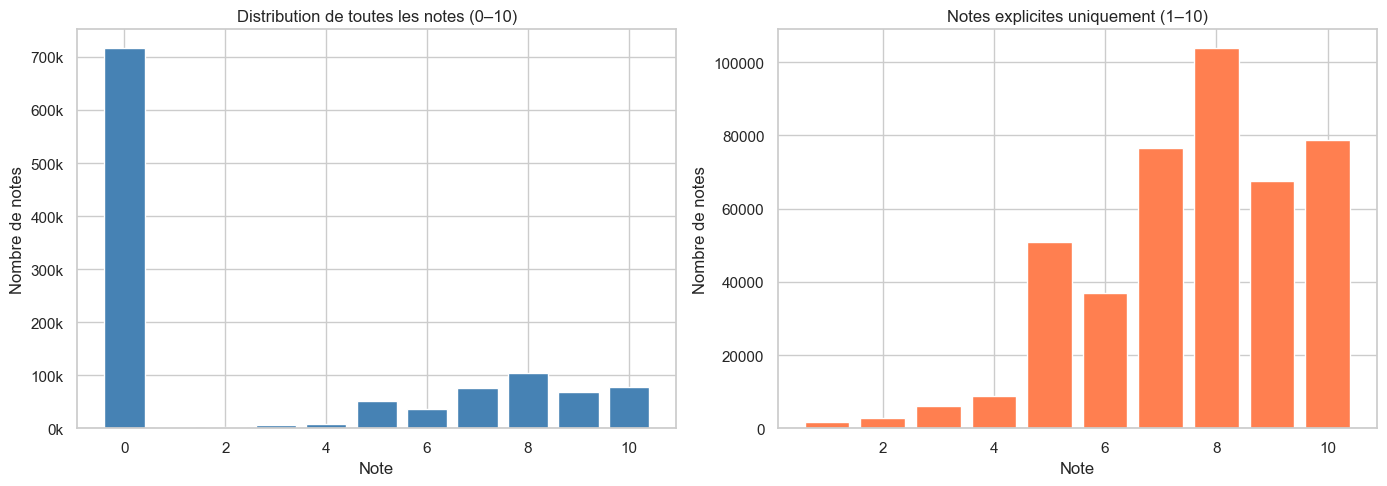

Notes implicites (0)  :  716,109 (62.3%)
Notes explicites (1–10):  433,671 (37.7%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution complète
rating_counts = ratings['Rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de toutes les notes (0–10)')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre de notes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))

# Notes explicites uniquement (1–10)
explicit = ratings[ratings['Rating'] > 0]
rating_counts_ex = explicit['Rating'].value_counts().sort_index()
axes[1].bar(rating_counts_ex.index, rating_counts_ex.values, color='coral', edgecolor='white')
axes[1].set_title('Notes explicites uniquement (1–10)')
axes[1].set_xlabel('Note')
axes[1].set_ylabel('Nombre de notes')

plt.tight_layout()
plt.savefig('../models/rating_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Notes implicites (0)  : {(ratings["Rating"]==0).sum():>8,} ({(ratings["Rating"]==0).mean()*100:.1f}%)')
print(f'Notes explicites (1–10): {(ratings["Rating"]>0).sum():>8,} ({(ratings["Rating"]>0).mean()*100:.1f}%)')

### 4.2 Activité des utilisateurs

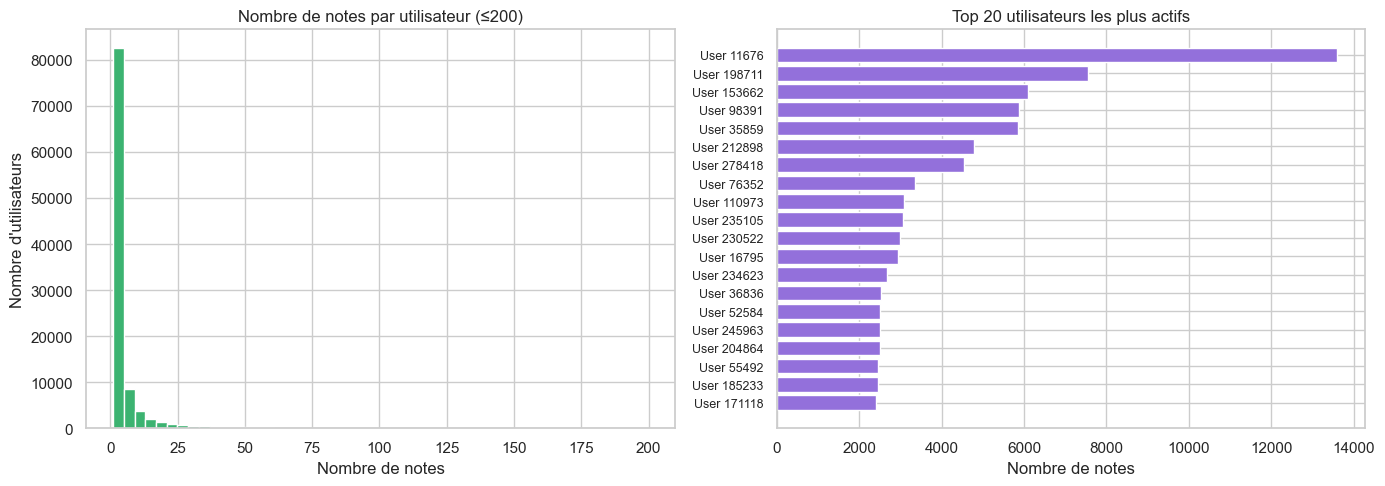

Médiane notes/utilisateur : 1
Moyenne notes/utilisateur : 10.9
Max notes/utilisateur     : 13,602


In [9]:
user_activity = ratings.groupby('User_ID')['Rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(user_activity[user_activity <= 200], bins=50, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Nombre de notes par utilisateur (≤200)')
axes[0].set_xlabel('Nombre de notes')
axes[0].set_ylabel('Nombre d\'utilisateurs')

# Top 20 utilisateurs
top_users = user_activity.head(20)
axes[1].barh(range(20), top_users.values, color='mediumpurple', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'User {u}' for u in top_users.index], fontsize=9)
axes[1].set_title('Top 20 utilisateurs les plus actifs')
axes[1].set_xlabel('Nombre de notes')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../models/user_activity.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Médiane notes/utilisateur : {user_activity.median():.0f}')
print(f'Moyenne notes/utilisateur : {user_activity.mean():.1f}')
print(f'Max notes/utilisateur     : {user_activity.max():,}')

### 4.3 Popularité des livres

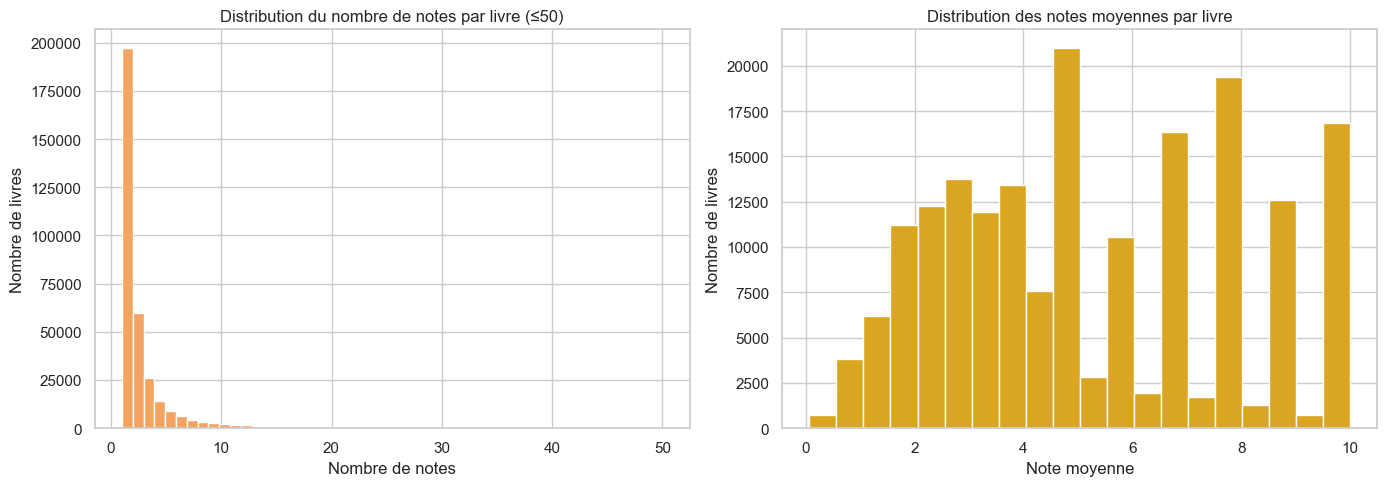

Livres avec ≥10 notes : 18,319
Livres avec ≥50 notes : 2,185


In [10]:
book_ratings = ratings.groupby('ISBN')['Rating'].agg(['count', 'mean']).reset_index()
book_ratings.columns = ['ISBN', 'Num_Ratings', 'Avg_Rating']
book_ratings = book_ratings.merge(books[['ISBN', 'Title', 'Author']], on='ISBN', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du nombre de notes par livre
axes[0].hist(book_ratings['Num_Ratings'][book_ratings['Num_Ratings'] <= 50], 
             bins=50, color='sandybrown', edgecolor='white')
axes[0].set_title('Distribution du nombre de notes par livre (≤50)')
axes[0].set_xlabel('Nombre de notes')
axes[0].set_ylabel('Nombre de livres')

# Distribution de la note moyenne
explicit_books = book_ratings[book_ratings['Avg_Rating'] > 0]
axes[1].hist(explicit_books['Avg_Rating'], bins=20, color='goldenrod', edgecolor='white')
axes[1].set_title('Distribution des notes moyennes par livre')
axes[1].set_xlabel('Note moyenne')
axes[1].set_ylabel('Nombre de livres')

plt.tight_layout()
plt.savefig('../models/book_popularity.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Livres avec ≥10 notes : {(book_ratings["Num_Ratings"]>=10).sum():,}')
print(f'Livres avec ≥50 notes : {(book_ratings["Num_Ratings"]>=50).sum():,}')

### 4.4 Top auteurs & éditeurs

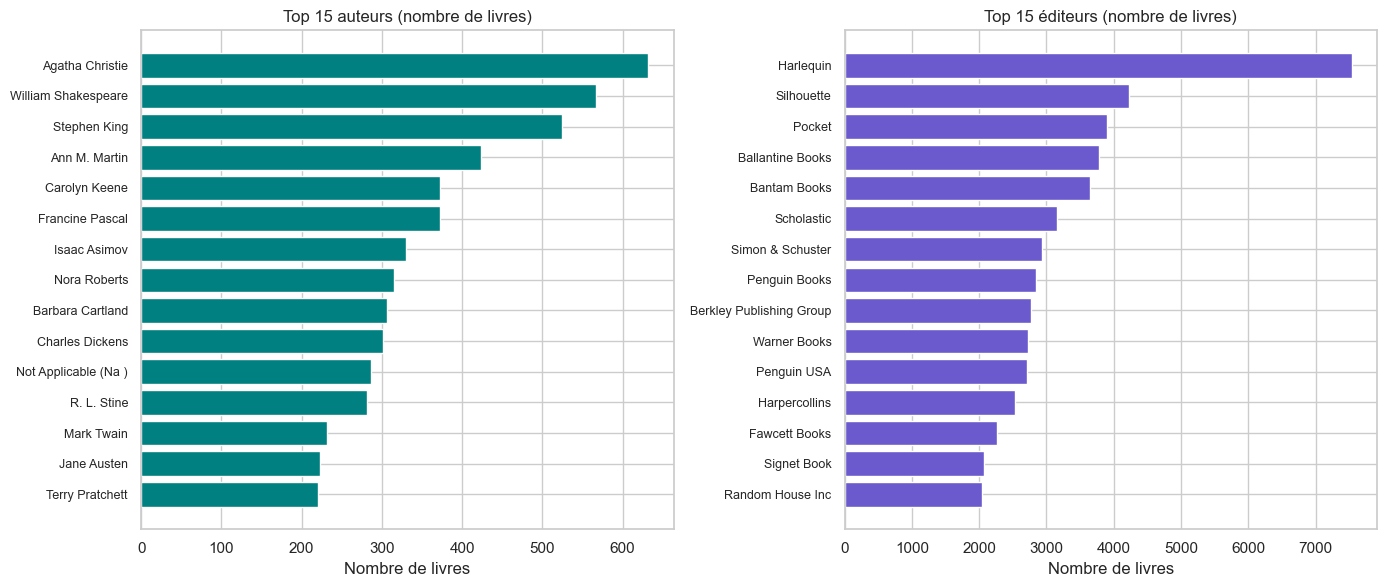

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 auteurs par nombre de livres
top_authors = books['Author'].value_counts().head(15)
axes[0].barh(range(len(top_authors)), top_authors.values, color='teal', edgecolor='white')
axes[0].set_yticks(range(len(top_authors)))
axes[0].set_yticklabels(top_authors.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 auteurs (nombre de livres)')
axes[0].set_xlabel('Nombre de livres')

# Top 15 éditeurs
top_publishers = books['Publisher'].value_counts().head(15)
axes[1].barh(range(len(top_publishers)), top_publishers.values, color='slateblue', edgecolor='white')
axes[1].set_yticks(range(len(top_publishers)))
axes[1].set_yticklabels(top_publishers.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 éditeurs (nombre de livres)')
axes[1].set_xlabel('Nombre de livres')

plt.tight_layout()
plt.savefig('../models/top_authors_publishers.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.5 Distribution des âges des utilisateurs

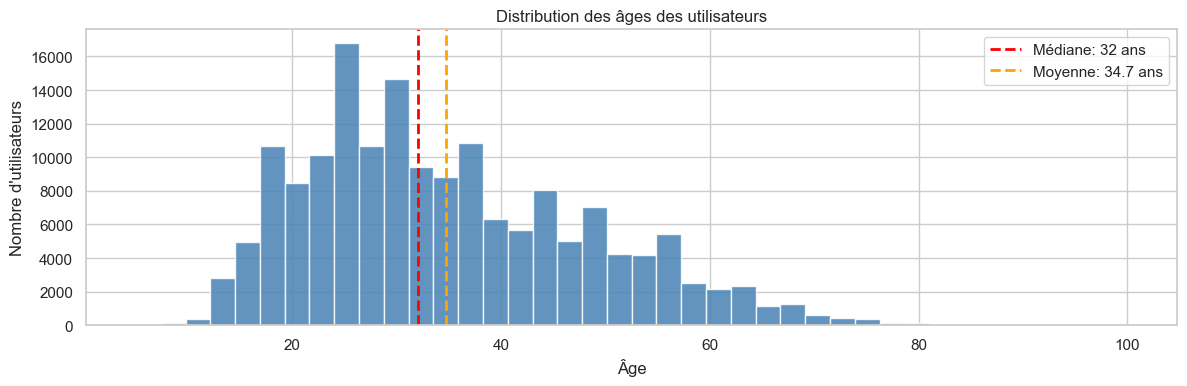

Utilisateurs avec âge valide : 165,917 / 278,859


In [12]:
valid_ages = users[(users['Age'] >= 5) & (users['Age'] <= 100)]['Age']

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(valid_ages, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(valid_ages.median(), color='red', linestyle='--', linewidth=2, label=f'Médiane: {valid_ages.median():.0f} ans')
ax.axvline(valid_ages.mean(), color='orange', linestyle='--', linewidth=2, label=f'Moyenne: {valid_ages.mean():.1f} ans')
ax.set_title('Distribution des âges des utilisateurs')
ax.set_xlabel('Âge')
ax.set_ylabel('Nombre d\'utilisateurs')
ax.legend()
plt.tight_layout()
plt.savefig('../models/age_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Utilisateurs avec âge valide : {len(valid_ages):,} / {len(users):,}')

## 5. Systèmes de Recommandation

### 5.1 Recommandation par Popularité (Baseline)

In [13]:
# On utilise uniquement les notes explicites (1–10)
explicit_ratings = ratings[ratings['Rating'] > 0].copy()

# Agrégation par livre
book_stats = explicit_ratings.groupby('ISBN').agg(
    Num_Ratings=('Rating', 'count'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

# Score pondéré (Bayesian average) — pénalise les livres peu notés
C = book_stats['Avg_Rating'].mean()   # note globale moyenne
m = 50                                 # seuil minimum de votes

book_stats['Weighted_Score'] = (
    (book_stats['Num_Ratings'] / (book_stats['Num_Ratings'] + m)) * book_stats['Avg_Rating'] +
    (m / (book_stats['Num_Ratings'] + m)) * C
)

# Fusionner avec les métadonnées
popular_books = book_stats.merge(books[['ISBN', 'Title', 'Author', 'Year', 'Publisher']], 
                                  on='ISBN', how='left')
popular_books = popular_books.sort_values('Weighted_Score', ascending=False).reset_index(drop=True)

print('=== Top 10 livres les plus populaires ===')
display_cols = ['Title', 'Author', 'Num_Ratings', 'Avg_Rating', 'Weighted_Score']
popular_books[display_cols].head(10).style.format({'Avg_Rating': '{:.2f}', 'Weighted_Score': '{:.3f}'})

=== Top 10 livres les plus populaires ===


,Title,Author,Num_Ratings,Avg_Rating,Weighted_Score
0,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,137,9.26,8.789
1,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling,313,8.94,8.740
2,Harry Potter and the Order of the Phoenix (Book 5),J. K. Rowling,206,9.03,8.733
3,To Kill a Mockingbird,Harper Lee,214,8.94,8.669
4,"The Return of the King (The Lord of the Rings, Part 3)",J.R.R. TOLKIEN,77,9.40,8.650
5,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,133,9.08,8.648
6,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,141,9.04,8.631
7,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,119,8.98,8.542
8,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,126,8.92,8.515
9,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,189,8.78,8.513


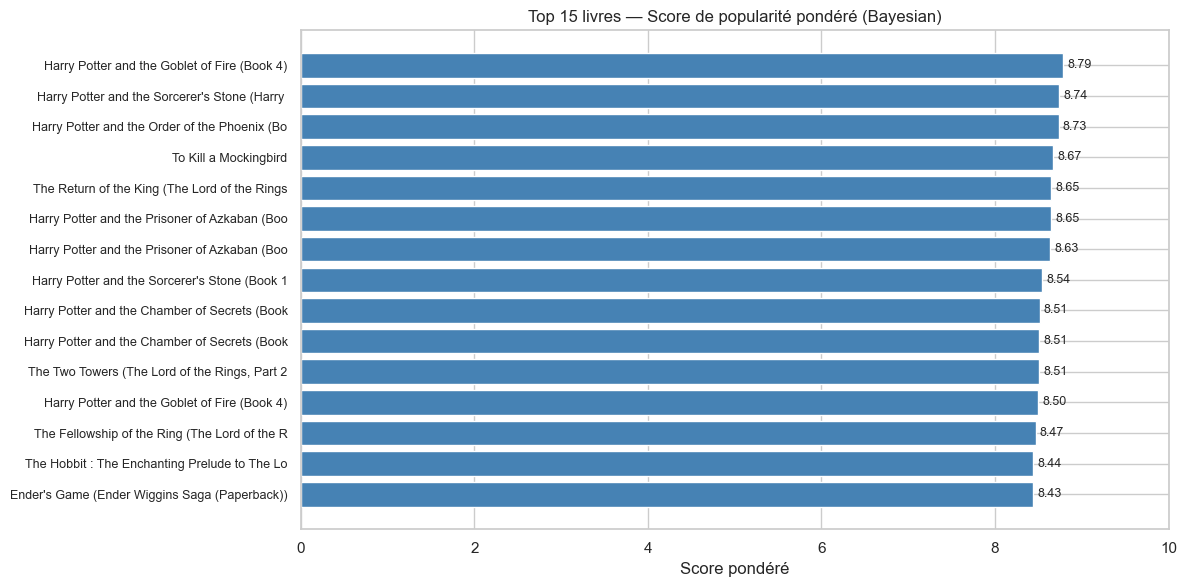

In [14]:
# Visualisation du top 15
top15 = popular_books.head(15).copy()
top15['Short_Title'] = top15['Title'].str[:45]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top15)), top15['Weighted_Score'], color='steelblue', edgecolor='white')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Short_Title'], fontsize=9)
ax.invert_yaxis()
ax.set_title('Top 15 livres — Score de popularité pondéré (Bayesian)')
ax.set_xlabel('Score pondéré')
ax.set_xlim(0, 10)

# Ajouter les valeurs
for i, (bar, score) in enumerate(zip(bars, top15['Weighted_Score'])):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{score:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../models/top15_popular_books.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# Sauvegarder le modèle de popularité
with open('../models/popular_books.pkl', 'wb') as f:
    pickle.dump(popular_books, f)

print('✓ Modèle de popularité sauvegardé')

✓ Modèle de popularité sauvegardé


### 5.2 Filtrage Collaboratif Item-Item

In [16]:
# Filtrage pour réduire la dimensionnalité
MIN_BOOK_RATINGS  = 50   # Livres avec au moins 50 notes
MIN_USER_RATINGS  = 50   # Utilisateurs avec au moins 50 notes

# Filtrer les livres
book_counts = explicit_ratings.groupby('ISBN')['Rating'].count()
qualified_books = book_counts[book_counts >= MIN_BOOK_RATINGS].index

# Filtrer les utilisateurs
user_counts = explicit_ratings.groupby('User_ID')['Rating'].count()
qualified_users = user_counts[user_counts >= MIN_USER_RATINGS].index

# Construire le sous-ensemble filtré
filtered = explicit_ratings[
    explicit_ratings['ISBN'].isin(qualified_books) &
    explicit_ratings['User_ID'].isin(qualified_users)
].copy()

print(f'Livres qualifiés (≥{MIN_BOOK_RATINGS} notes) : {len(qualified_books):,}')
print(f'Users qualifiés (≥{MIN_USER_RATINGS} notes)  : {len(qualified_users):,}')
print(f'Notes dans le sous-ensemble filtré          : {len(filtered):,}')

Livres qualifiés (≥50 notes) : 537
Users qualifiés (≥50 notes)  : 1,332
Notes dans le sous-ensemble filtré          : 14,288


In [17]:
# Construire la matrice Utilisateur × Livre
pivot = filtered.pivot_table(
    index='User_ID', 
    columns='ISBN', 
    values='Rating',
    aggfunc='mean'
).fillna(0)

print(f'Matrice User×Book : {pivot.shape[0]} utilisateurs × {pivot.shape[1]} livres')
sparsity = 1 - (filtered.shape[0] / (pivot.shape[0] * pivot.shape[1]))
print(f'Sparsité           : {sparsity*100:.1f}%')

Matrice User×Book : 1210 utilisateurs × 537 livres
Sparsité           : 97.8%


In [18]:
# Calculer la similarité cosinus entre livres (item-item)
book_matrix = csr_matrix(pivot.T.values)
item_similarity = cosine_similarity(book_matrix)

# DataFrame de similarité
isbn_list = pivot.columns.tolist()
item_sim_df = pd.DataFrame(item_similarity, index=isbn_list, columns=isbn_list)

print(f'Matrice de similarité item-item : {item_sim_df.shape}')

Matrice de similarité item-item : (537, 537)


In [19]:
def get_cf_recommendations(isbn, n=10, sim_df=item_sim_df, books_df=books):
    """Retourne les n livres les plus similaires à un ISBN donné (filtrage collaboratif)."""
    if isbn not in sim_df.index:
        return pd.DataFrame(columns=['ISBN', 'Title', 'Author', 'Similarity'])
    
    scores = sim_df[isbn].sort_values(ascending=False).iloc[1:n+1]
    result = scores.reset_index()
    result.columns = ['ISBN', 'Similarity']
    result = result.merge(books_df[['ISBN', 'Title', 'Author', 'Year']], on='ISBN', how='left')
    return result[['ISBN', 'Title', 'Author', 'Year', 'Similarity']]


# Test — utiliser le premier ISBN du corpus filtré
test_isbn = isbn_list[0]
test_title = books[books['ISBN'] == test_isbn]['Title'].values
test_title = test_title[0] if len(test_title) > 0 else 'Unknown'

print(f'Recommandations pour : "{test_title}" ({test_isbn})')
print('=' * 70)
recs = get_cf_recommendations(test_isbn)
recs[['Title', 'Author', 'Similarity']].style.format({'Similarity': '{:.3f}'})

Recommandations pour : "Politically Correct Bedtime Stories: Modern Tales for Our Life and Times" (002542730X)


,Title,Author,Similarity
0,The Hundred Secret Senses,Amy Tan,0.162
1,Free,Paul Vincent,0.150
2,About a Boy,Nick Hornby,0.149
3,Pay It Forward,Catherine Ryan Hyde,0.148
4,Beach Music,Pat Conroy,0.142
5,"The Bad Beginning (A Series of Unfortunate Events, Book 1)",Lemony Snicket,0.135
6,What to Expect the First Year,Arlene Eisenberg,0.130
7,nan,nan,0.129
8,One True Thing,Anna Quindlen,0.129
9,Five Quarters of the Orange,Joanne Harris,0.129


In [20]:
# Sauvegarder le modèle CF
cf_model = {
    'item_sim_df'  : item_sim_df,
    'isbn_list'    : isbn_list,
    'books_in_model': books[books['ISBN'].isin(isbn_list)].copy()
}

with open('../models/cf_model.pkl', 'wb') as f:
    pickle.dump(cf_model, f)

print('✓ Modèle CF item-item sauvegardé')

✓ Modèle CF item-item sauvegardé


### 5.3 Recommandation Basée sur le Contenu (TF-IDF)

In [21]:
# On travaille sur les livres présents dans notre corpus filtré
content_books = books[books['ISBN'].isin(isbn_list)].copy().reset_index(drop=True)

# Construire le champ texte : Titre + Auteur (répété pour lui donner plus de poids)
content_books['Text'] = (
    content_books['Title'].fillna('') + ' ' +
    content_books['Author'].fillna('') + ' ' +
    content_books['Author'].fillna('')  # auteur × 2
)

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)
tfidf_matrix = tfidf.fit_transform(content_books['Text'])

print(f'Matrice TF-IDF : {tfidf_matrix.shape[0]} livres × {tfidf_matrix.shape[1]} termes')

Matrice TF-IDF : 531 livres × 831 termes


In [22]:
# Similarité cosinus basée sur le contenu
content_sim = cosine_similarity(tfidf_matrix)
content_sim_df = pd.DataFrame(
    content_sim,
    index=content_books['ISBN'],
    columns=content_books['ISBN']
)

print(f'Matrice similarité contenu : {content_sim_df.shape}')

Matrice similarité contenu : (531, 531)


In [23]:
def get_content_recommendations(isbn, n=10, sim_df=content_sim_df, books_df=content_books):
    """Retourne les n livres au contenu similaire (TF-IDF + cosinus)."""
    if isbn not in sim_df.index:
        return pd.DataFrame(columns=['ISBN', 'Title', 'Author', 'Similarity'])

    scores = sim_df[isbn].sort_values(ascending=False).iloc[1:n+1]
    result = scores.reset_index()
    result.columns = ['ISBN', 'Similarity']
    result = result.merge(books_df[['ISBN', 'Title', 'Author', 'Year']], on='ISBN', how='left')
    return result[['ISBN', 'Title', 'Author', 'Year', 'Similarity']]


print(f'Recommandations contenu pour : "{test_title}"')
print('=' * 70)
get_content_recommendations(test_isbn)[['Title', 'Author', 'Similarity']].style.format({'Similarity': '{:.3f}'})

Recommandations contenu pour : "Politically Correct Bedtime Stories: Modern Tales for Our Life and Times"


,Title,Author,Similarity
0,The Celestine Prophecy (Celestine Prophecy),James Redfield,0.562
1,The Color of Water: A Black Man's Tribute to His White Mother,James McBride,0.305
2,Pop Goes the Weasel,James Patterson,0.301
3,When the Wind Blows,James Patterson,0.301
4,Cradle and All,James Patterson,0.301
5,Wicked: The Life and Times of the Wicked Witch of the West,Gregory Maguire,0.291
6,Kiss the Girls,James Patterson,0.281
7,Four Blind Mice,James Patterson,0.259
8,The Beach House,James Patterson,0.238
9,The Beach House,James Patterson,0.238


In [24]:
# Sauvegarder le modèle content-based
cb_model = {
    'content_sim_df' : content_sim_df,
    'content_books'  : content_books,
    'tfidf'          : tfidf
}

with open('../models/cb_model.pkl', 'wb') as f:
    pickle.dump(cb_model, f)

print('✓ Modèle content-based sauvegardé')

✓ Modèle content-based sauvegardé


### 5.4 Recommandation Hybride

In [25]:
def get_hybrid_recommendations(isbn, n=10, alpha=0.6):
    """
    Recommandation hybride : combine CF (poids alpha) + content (poids 1-alpha).
    alpha : poids accordé au filtrage collaboratif
    """
    if isbn not in item_sim_df.index or isbn not in content_sim_df.index:
        return pd.DataFrame()

    cf_scores   = item_sim_df[isbn].drop(isbn)
    cb_scores   = content_sim_df[isbn].drop(isbn)

    # Aligner les index
    common_isbn = cf_scores.index.intersection(cb_scores.index)
    hybrid = alpha * cf_scores[common_isbn] + (1 - alpha) * cb_scores[common_isbn]
    hybrid = hybrid.sort_values(ascending=False).head(n)

    result = hybrid.reset_index()
    result.columns = ['ISBN', 'Score_Hybride']
    result = result.merge(books[['ISBN', 'Title', 'Author', 'Year']], on='ISBN', how='left')
    return result[['ISBN', 'Title', 'Author', 'Year', 'Score_Hybride']]


print(f'Recommandations hybrides pour : "{test_title}"')
print('=' * 70)
get_hybrid_recommendations(test_isbn)[['Title', 'Author', 'Score_Hybride']].style.format({'Score_Hybride': '{:.3f}'})

Recommandations hybrides pour : "Politically Correct Bedtime Stories: Modern Tales for Our Life and Times"


,Title,Author,Score_Hybride
0,The Celestine Prophecy (Celestine Prophecy),James Redfield,0.275
1,Wicked: The Life and Times of the Wicked Witch of the West,Gregory Maguire,0.180
2,The Color of Water: A Black Man's Tribute to His White Mother,James McBride,0.179
3,1st to Die: A Novel,James Patterson,0.155
4,Pop Goes the Weasel,James Patterson,0.135
5,Cradle and All,James Patterson,0.131
6,Kiss the Girls,James Patterson,0.131
7,Four Blind Mice,James Patterson,0.131
8,Along Came a Spider (Alex Cross Novels),James Patterson,0.130
9,2nd Chance,James Patterson,0.128


## 6. Évaluation des Modèles

In [26]:
# Évaluation par precision@k et recall@k (hold-out 20%)
from sklearn.model_selection import train_test_split

# Sous-ensemble pour l'évaluation
eval_users = filtered['User_ID'].value_counts()
eval_users = eval_users[eval_users >= 20].index[:500]  # 500 utilisateurs max
eval_data  = filtered[filtered['User_ID'].isin(eval_users)]

# Split train/test par utilisateur
train_list, test_list = [], []
for uid, group in eval_data.groupby('User_ID'):
    if len(group) < 4:
        continue
    tr, te = train_test_split(group, test_size=0.2, random_state=42)
    train_list.append(tr)
    test_list.append(te)

train_eval = pd.concat(train_list)
test_eval  = pd.concat(test_list)

print(f'Train : {len(train_eval):,} notes | Test : {len(test_eval):,} notes')

Train : 4,851 notes | Test : 1,316 notes


In [27]:
def precision_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / k if k > 0 else 0.0

def recall_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / len(relevant) if relevant else 0.0


# Évaluer CF item-item
def evaluate_cf(test_df, train_df, k=10):
    precisions, recalls = [], []

    for uid, test_group in test_df.groupby('User_ID'):
        relevant = test_group[test_group['Rating'] >= 7]['ISBN'].tolist()
        if not relevant:
            continue

        # Livres déjà notés en train
        seen_isbns = train_df[train_df['User_ID'] == uid]['ISBN'].unique()

        # Agrégation des recommandations CF pour les livres vus
        all_scores = {}
        for isbn in seen_isbns:
            if isbn not in item_sim_df.index:
                continue
            scores = item_sim_df[isbn].drop(isbn, errors='ignore')
            for rec_isbn, score in scores.items():
                if rec_isbn not in seen_isbns:
                    all_scores[rec_isbn] = all_scores.get(rec_isbn, 0) + score

        recommended = sorted(all_scores, key=all_scores.get, reverse=True)[:k]
        precisions.append(precision_at_k(recommended, relevant, k))
        recalls.append(recall_at_k(recommended, relevant, k))

    return np.mean(precisions), np.mean(recalls)


p_cf, r_cf = evaluate_cf(test_eval, train_eval, k=10)
print(f'=== Évaluation Filtrage Collaboratif @ k=10 ===')
print(f'Précision@10 : {p_cf:.4f}')
print(f'Rappel@10    : {r_cf:.4f}')
f1_cf = 2 * p_cf * r_cf / (p_cf + r_cf) if (p_cf + r_cf) > 0 else 0
print(f'F1@10        : {f1_cf:.4f}')

=== Évaluation Filtrage Collaboratif @ k=10 ===
Précision@10 : 0.3061
Rappel@10    : 0.5581
F1@10        : 0.3953


In [28]:
# Comparaison des méthodes
results = {
    'Filtrage Collaboratif': {'Précision@10': p_cf, 'Rappel@10': r_cf, 'F1@10': f1_cf},
}

results_df = pd.DataFrame(results).T
print('=== Tableau comparatif des modèles ===')
results_df.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0)

=== Tableau comparatif des modèles ===


,Précision@10,Rappel@10,F1@10
Filtrage Collaboratif,0.3061,0.5581,0.3953


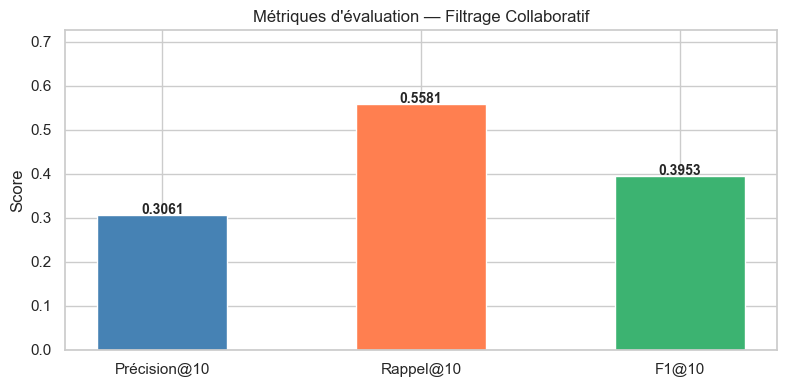

In [29]:
# Graphique d'évaluation
fig, ax = plt.subplots(figsize=(8, 4))

metrics = ['Précision@10', 'Rappel@10', 'F1@10']
values  = [p_cf, r_cf, f1_cf]
colors  = ['steelblue', 'coral', 'mediumseagreen']

bars = ax.bar(metrics, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Métriques d\'évaluation — Filtrage Collaboratif')
ax.set_ylabel('Score')
ax.set_ylim(0, max(values) * 1.3)
plt.tight_layout()
plt.savefig('../models/evaluation_metrics.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Sauvegarde Finale & Résumé

In [30]:
# Sauvegarder le catalogue complet des livres filtrés
books_catalog = books[books['ISBN'].isin(isbn_list)].copy()
books_catalog.to_csv('../models/books_catalog.csv', index=False)

# Sauvegarder les statistiques de popularité
popular_books.to_csv('../models/popular_books.csv', index=False)

# Vérifier tous les fichiers générés
import os
print('=== Fichiers générés dans models/ ===')
for f in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f'  {f:<35} {size:>8.1f} KB')

=== Fichiers générés dans models/ ===
  age_distribution.png                    29.8 KB
  book_popularity.png                     36.2 KB
  books_catalog.csv                       38.5 KB
  cb_model.pkl                          2328.0 KB
  cf_model.pkl                          2339.0 KB
  evaluation_metrics.png                  19.6 KB
  popular_books.csv                    18085.4 KB
  popular_books.pkl                    23364.8 KB
  rating_distribution.png                 29.1 KB
  top15_popular_books.png                 63.2 KB
  top_authors_publishers.png              55.4 KB
  user_activity.png                       55.3 KB


In [31]:
print('\n' + '='*60)
print('       RÉSUMÉ DU PROJET')
print('='*60)
print(f'Dataset : Book-Crossing')
print(f'  - {len(books):,} livres | {len(ratings):,} notes | {len(users):,} users')
print(f'Corpus filtré :')
print(f'  - {len(isbn_list):,} livres | {len(pivot):,} utilisateurs')
print()
print('Modèles entraînés :')
print('  1. Popularité (Bayesian Weighted Score)')
print('  2. Filtrage Collaboratif Item-Item (cosine similarity)')
print('  3. Content-Based (TF-IDF + cosine similarity)')
print('  4. Hybride (CF × 0.6 + CB × 0.4)')
print()
print('Évaluation (CF @ k=10) :')
print(f'  Précision : {p_cf:.4f}')
print(f'  Rappel    : {r_cf:.4f}')
print(f'  F1        : {f1_cf:.4f}')
print('='*60)


       RÉSUMÉ DU PROJET
Dataset : Book-Crossing
  - 271,378 livres | 1,149,780 notes | 278,859 users
Corpus filtré :
  - 537 livres | 1,210 utilisateurs

Modèles entraînés :
  1. Popularité (Bayesian Weighted Score)
  2. Filtrage Collaboratif Item-Item (cosine similarity)
  3. Content-Based (TF-IDF + cosine similarity)
  4. Hybride (CF × 0.6 + CB × 0.4)

Évaluation (CF @ k=10) :
  Précision : 0.3061
  Rappel    : 0.5581
  F1        : 0.3953
